# Neuronavigation Script

This notebook is used for the various moments of the pipeline where images have to be transformed, reoriented or sliced between different spaces.

The *first section* of this notebook identifies imaged slices at the population level for slicing purpose (angio -> fusi spaces)

- Needs the parameter images (allen, template, masks...) as well as the individual 3D transforms
- loads the files
- Estimates true imaging positions and displays them

The *second section* (requires the previous one to have been run previously) slices parameters accordingly

- Slices param files
- export QC images
- generate masks is a patch to generate masks based on already sliced images

The *third* and *fourth* sections should be run one after the other to transform images from full volume allen-25um (allowing extraction of high resolution parameters) to sequentially:
- The high resolution fUSI space (volume)
- and low resolution fUSI space (volume)
- sliced version of both



In [2]:
import re

import numpy as np
import nibabel as nib
import colorcet as cc
import pandas as pd

import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm

from nilearn.masking import apply_mask, unmask
from nilearn.image import resample_img
from scipy.ndimage import gaussian_filter, binary_fill_holes
from nipype.interfaces.ants import ApplyTransforms

# Low resolution slicing

The following cells are used for estimation of the imaged slices at the population level based on the transform of the true position of imaged slice on the template.

## Parameters

In [3]:
template_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz')
template_img = nib.load(template_name)

[X,Y,Z] = template_img.shape

mask_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-Wang2020_space-fUSI_desc-AllenMask_res-110umx100umx100um_feature.nii.gz')
mask_img = nib.load(mask_name)

allen_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-Wang2020_space-fUSI_desc-AllenTemplate_res-110umx100umx100um_feature.nii.gz')
allen_img = nib.load(allen_name)

wmcsf_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-Gozzilab_space-fUSI_desc-WMCSFmask_res-110umx110umx100um_feature.nii.gz')
wmcsf_img = nib.load(wmcsf_name)

root_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-minc/')

pose_files = {}

for i in range(4):

    pose_files[f'pose-{i}'] = sorted(
        [x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*pose-{i}.*.nii.gz$', x.name)]
    )

## Loads

In [18]:
pose_density = np.zeros(template_img.shape + (4,))

for i in range(4):

    for file_name in pose_files[f'pose-{i}']:

        img = nib.load(file_name)
        pose_density[:,:,:,i] = pose_density[:,:,:,i] + img.get_fdata()

pose_density_smooth = gaussian_filter(pose_density, sigma=1)

## Display slices

Estimates the ground truth, give the estimated position of slices, display the estimated slice-wise templates.

/tmp/ipykernel_183910/932589895.py:7: RuntimeWarning: invalid value encountered in log10
  img_2_display = np.rot90(np.log10(template_img.get_fdata()[:,:,sagittal_slice_id]))


pose-0: 23
pose-1: 33
pose-2: 43
pose-3: 53


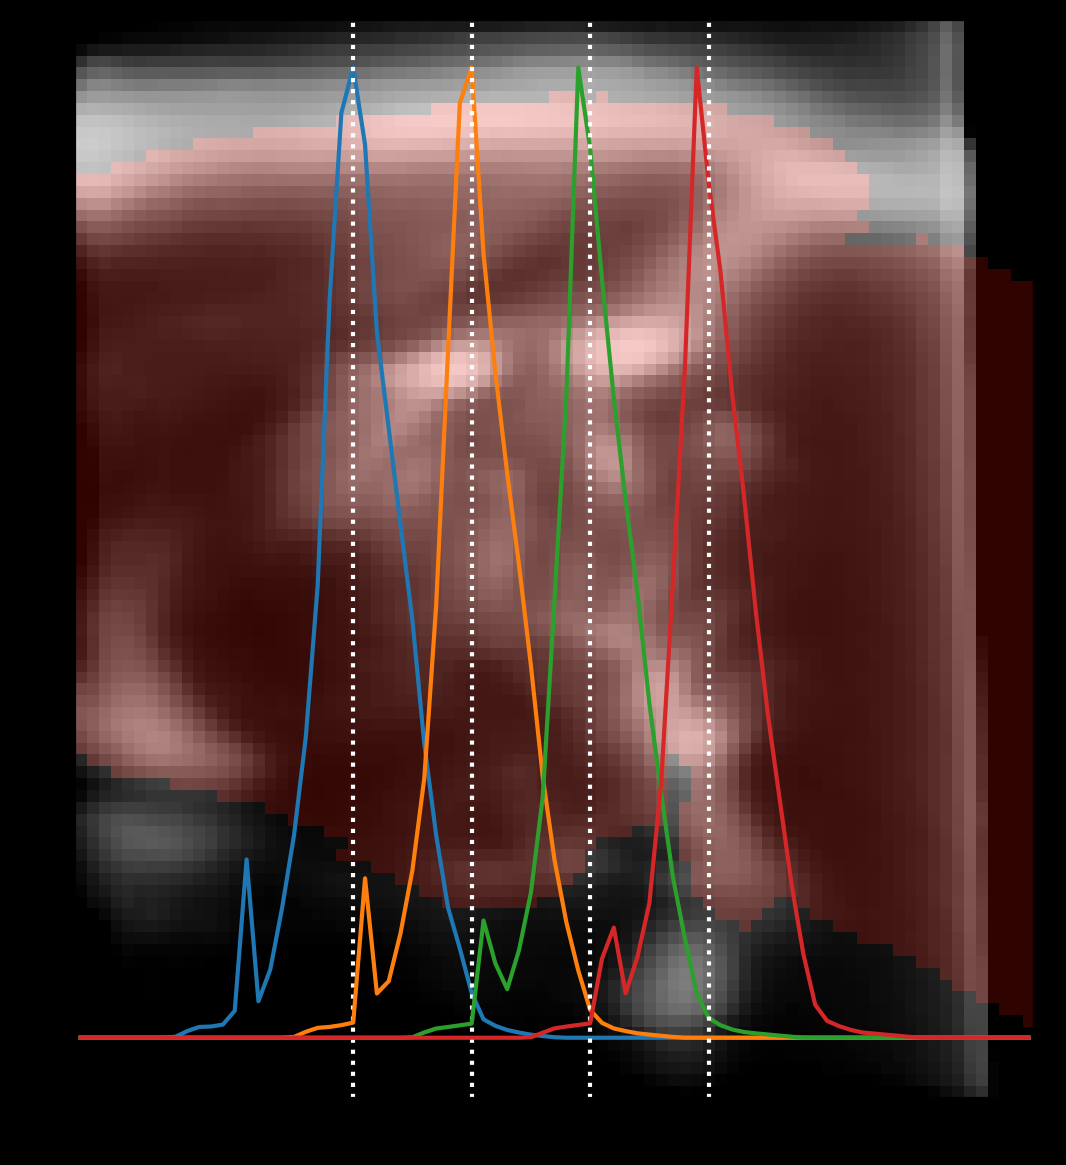

In [33]:
plt.figure(figsize = (10,7), dpi = 200, facecolor = 'k')

slice_indices = []

sagittal_slice_id = 60

img_2_display = np.rot90(np.log10(template_img.get_fdata()[:,:,sagittal_slice_id]))
img_2_display[np.isinf(img_2_display)] = 0
img_2_display[np.isnan(img_2_display)] = 0
plt.imshow(img_2_display, aspect = 1, cmap = 'Greys_r', vmin = 0.8, vmax = 2.2, origin = 'lower')
img_2_display = np.rot90(mask_img.get_fdata()[:,:,sagittal_slice_id])
plt.imshow(img_2_display, aspect = 1, cmap = cc.cm['fire'], vmax = 2, alpha = .2, origin = 'lower')

sagittal_slice_id = 60

for pose_id in range(4):

    slice_density_profile = pose_density[:,:,:,pose_id].mean((1,2))
    
    yM = slice_density_profile.max()

    plt.plot(0.05*Y+0.9*Y*slice_density_profile/yM)

    # max estimator
    # slice_ind = int(np.argmax(slice_density_profile).squeeze())
    # median estimator
    slice_ind = np.argwhere(np.cumsum(slice_density_profile)>0.5*(slice_density_profile.sum())).squeeze()[0]
    plt.axvline(slice_ind, ls = ':', c = 'w')
    
    slice_indices.append(slice_ind)

# plt.xlim(0.5,X-0.5)
# plt.ylim(0.5,Y-0.5)

for i,x in enumerate(slice_indices):

    print(f'pose-{i}: {x}')

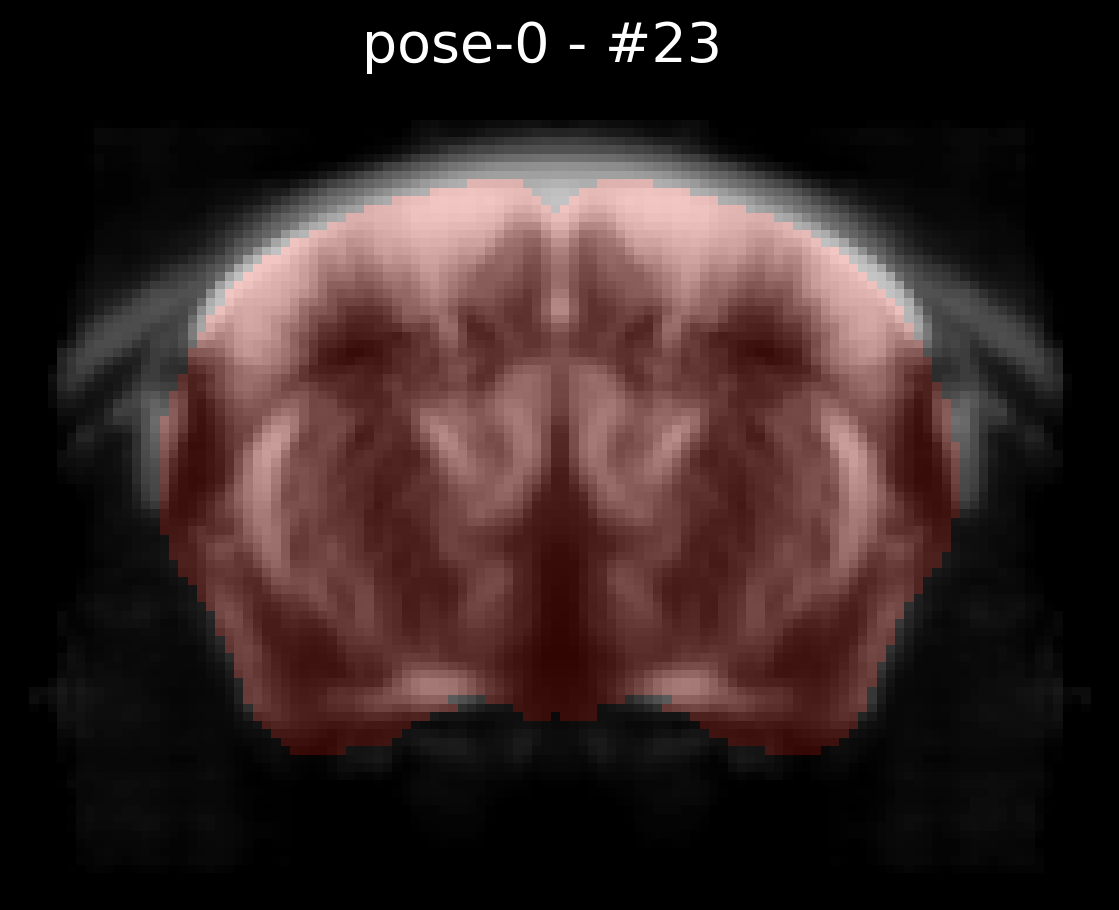

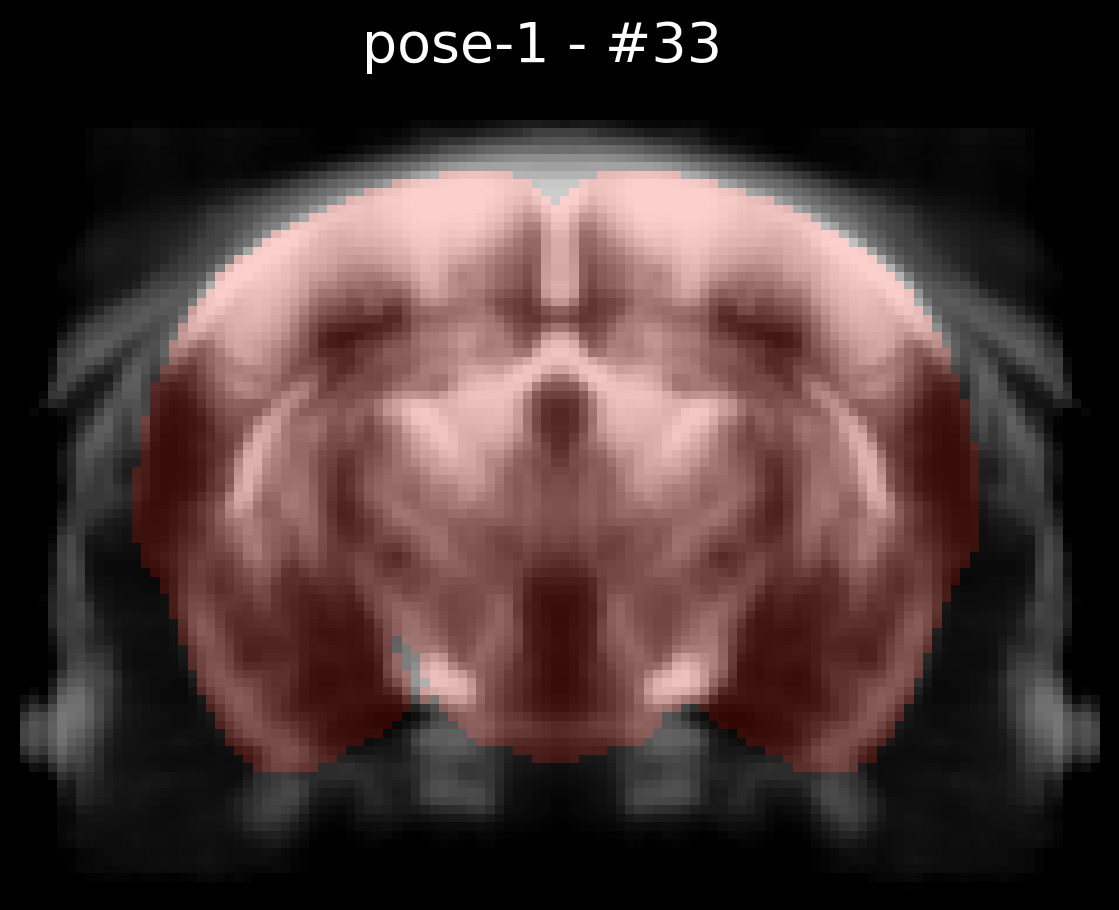

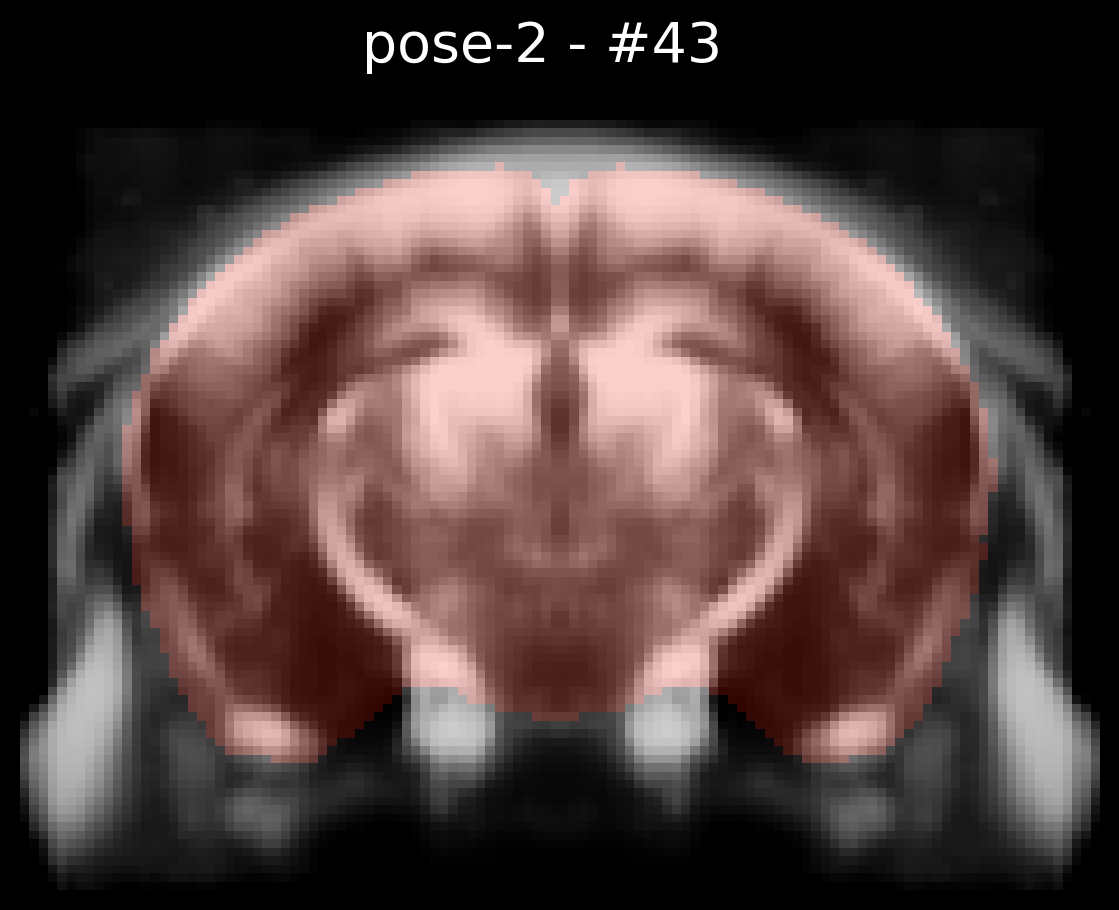

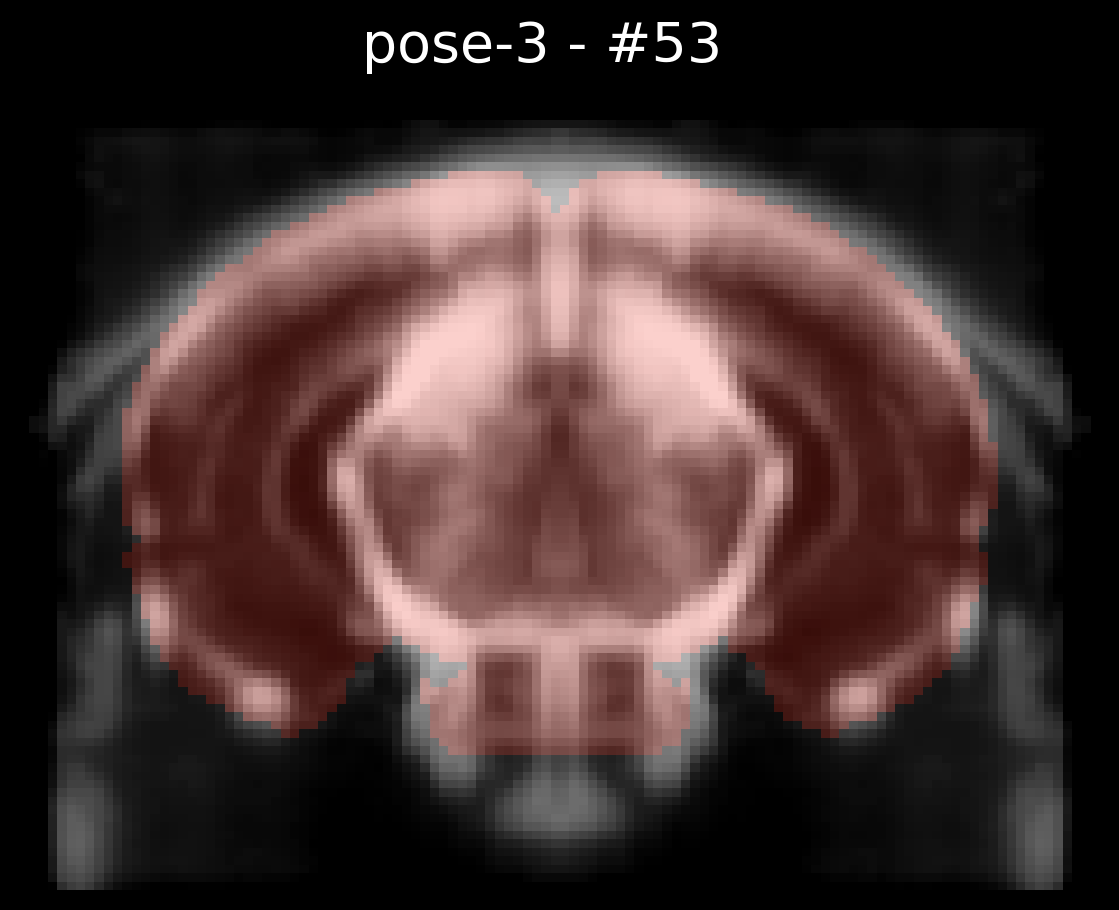

In [34]:
for i,x in enumerate(slice_indices):

    plt.figure(figsize = (7,5), dpi = 200, facecolor = 'k')

    img_2_display = np.log10(template_img.get_fdata()[x,:,:])
    
    plt.imshow(img_2_display, cmap = 'Greys_r', vmin = 0.8, vmax = 2.2, aspect = 0.1/0.11)

    img_2_display = mask_img.get_fdata()[x,:,:]
    
    plt.imshow(img_2_display, cmap = cc.cm['fire'], vmin = 0, vmax = 2, aspect = 0.1/0.11, alpha = 0.2)
    
    plt.axis('off')

    plt.suptitle(f'pose-{i} - #{x}', fontsize = 20, c = 'w')

# Export slices

The following cells based on the previous estimate of slice position automatically slices parameter files in the template space:
- Allen template
- fUSI template
- log(fUSI template) *used for registration*
- Allen mask
- WMCSF mask

### Parameters

In [43]:
save_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/neuronavigation/2025-05-15_first-pass/1_data')
save_dir.mkdir(exist_ok = True, parents = True)

In [48]:
####################### Template Allen

img_data = np.zeros((len(slice_indices),)+allen_img.shape[1:])

for i, slice_idx in enumerate(slice_indices):

    img_data[i,:,:] = allen_img.get_fdata()[slice_idx,:,:]

    # individual slices

    img_out = nib.Nifti1Image(
        img_data[i,:,:][None,:,:],
        affine = allen_img.affine
    )

    nib.save(
        img_out,
        save_dir / f"pose-{i}_feature".join("space-fUSIswVBm40".join(allen_name.name.split("space-fUSI")).split("feature"))
    )

# whole volume

img_out = nib.Nifti1Image(
        img_data,
        affine = allen_img.affine
    )

nib.save(
    img_out,
    save_dir / f"pose-vol_feature".join("space-fUSIswVBm40".join(allen_name.name.split("space-fUSI")).split("feature"))
)

####################### Template Gillian

img_data = np.zeros((len(slice_indices),)+template_img.shape[1:])

for i, slice_idx in enumerate(slice_indices):

    img_data[i,:,:] = template_img.get_fdata()[slice_idx,:,:]

    # individual slices

    img_out = nib.Nifti1Image(
        img_data[i,:,:][None,:,:],
        affine = allen_img.affine
    )

    nib.save(
        img_out,
        save_dir / f"pose-{i}_feature".join("space-fUSIswVBm40".join(template_name.name.split("space-fUSI")).split("feature"))
    )

# whole volume

img_out = nib.Nifti1Image(
        img_data,
        affine = allen_img.affine
    )

nib.save(
    img_out,
    save_dir / f"pose-vol_feature".join("space-fUSIswVBm40".join(template_name.name.split("space-fUSI")).split("feature"))
)

####################### log Template Gillian

img_data = np.zeros((len(slice_indices),)+template_img.shape[1:])

for i, slice_idx in enumerate(slice_indices):

    img_slice = np.log10(template_img.get_fdata()[slice_idx,:,:])
    img_slice[np.isinf(img_slice)] = 0
    img_slice[np.isnan(img_slice)] = 0
    img_data[i,:,:] = img_slice

    # individual slices

    img_out = nib.Nifti1Image(
        img_data[i,:,:][None,:,:],
        affine = allen_img.affine
    )

    nib.save(
        img_out,
        save_dir / "dBGillianTemplate".join(f"pose-{i}_feature".join("space-fUSIswVBm40".join(template_name.name.split("space-fUSI")).split("feature")).split("GillianTemplate"))
    )

# whole volume

img_out = nib.Nifti1Image(
        img_data,
        affine = allen_img.affine
    )

nib.save(
    img_out,
    save_dir / "dBGillianTemplate".join(f"pose-vol_feature".join("space-fUSIswVBm40".join(template_name.name.split("space-fUSI")).split("feature")).split("GillianTemplate"))
)

####################### Mask

img_data = np.zeros((len(slice_indices),)+mask_img.shape[1:])

for i, slice_idx in enumerate(slice_indices):

    img_data[i,:,:] = mask_img.get_fdata()[slice_idx,:,:]

    # individual slices

    img_out = nib.Nifti1Image(
        img_data[i,:,:][None,:,:],
        affine = allen_img.affine
    )

    nib.save(
        img_out,
        save_dir / f"pose-{i}_feature".join("space-fUSIswVBm40".join(mask_name.name.split("space-fUSI")).split("feature"))
    )

# whole volume

img_out = nib.Nifti1Image(
        img_data,
        affine = allen_img.affine
    )

nib.save(
    img_out,
    save_dir / f"pose-vol_feature".join("space-fUSIswVBm40".join(mask_name.name.split("space-fUSI")).split("feature"))
)


In [51]:
####################### WMCSF

img_data = np.zeros((len(slice_indices),)+mask_img.shape[1:])

for i, slice_idx in enumerate(slice_indices):

    img_data[i,:,:] = wmcsf_img.get_fdata()[slice_idx,:,:]

    # individual slices

    img_out = nib.Nifti1Image(
        img_data[i,:,:][None,:,:],
        affine = allen_img.affine
    )

    nib.save(
        img_out,
        save_dir / f"pose-{i}_feature".join("space-fUSIswVBm40".join(wmcsf_name.name.split("space-fUSI")).split("feature"))
    )

# whole volume

img_out = nib.Nifti1Image(
        img_data,
        affine = allen_img.affine
    )

nib.save(
    img_out,
    save_dir / f"pose-vol_feature".join("space-fUSIswVBm40".join(wmcsf_name.name.split("space-fUSI")).split("feature"))
)

## Export QCs 

Displays associated QCs for the slicing procedure.

In [37]:
save_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/neuronavigation/2025-05-15_first-pass/2_visual')
save_dir.mkdir(exist_ok = True, parents = True)

In [38]:
for pose_id in range(4):
    
    for i in np.linspace(10,80,6).astype(int):
    
        plt.figure(figsize = (10,7), dpi = 200, facecolor = 'k')
    
        img_2_display = np.log10(template_img.get_fdata()[:,i,:])
        img_2_display[np.isinf(img_2_display)] = 0
        img_2_display[np.isnan(img_2_display)] = 0
        plt.imshow(img_2_display, aspect = 1, cmap = 'Greys_r', vmin = 0.8, vmax = 2.2, origin = 'lower')
        img_2_display = mask_img.get_fdata()[:,i,:]
        plt.imshow(img_2_display, aspect = 1, cmap = cc.cm['fire'], vmax = 2, alpha = .2, origin = 'lower')
    
        img_2_display = pose_density[:,i,:,pose_id]
        alpha = img_2_display>0
        
        plt.imshow(img_2_display, aspect = (0.1/0.1), cmap = cc.cm['fire'], alpha = 0.7*alpha)
    
        x = slice_indices[pose_id]
        
        plt.axhspan(x-2.5, x+2.5, facecolor = 'C4', alpha = 0.5)
    
        plt.axis('off')
    
        save_name = save_dir / f'02_slices_pose-{pose_id}_horizontal-{i}.png'
        plt.savefig(save_name)
        plt.close('all')

/tmp/ipykernel_183910/3571805258.py:7: RuntimeWarning: invalid value encountered in log10
  img_2_display = np.log10(template_img.get_fdata()[:,i,:])


In [39]:
for pose_id in range(4):

    for i in np.linspace(18,Z-18,6).astype(int):
    
        plt.figure(figsize = (10,7), dpi = 200, facecolor = 'k')
    
        img_2_display = np.rot90(np.log10(template_img.get_fdata()[:,:,i]))
        img_2_display[np.isinf(img_2_display)] = 0
        img_2_display[np.isnan(img_2_display)] = 0
        plt.imshow(img_2_display, aspect = 1, cmap = 'Greys_r', vmin = 0.8, vmax = 2.2, origin = 'lower')
        img_2_display = np.rot90(mask_img.get_fdata()[:,:,i])
        plt.imshow(img_2_display, aspect = 1, cmap = cc.cm['fire'], vmax = 2, alpha = .2, origin = 'lower')
    
        img_2_display = np.rot90(pose_density[:,:,i,pose_id])
        alpha = img_2_display>0
        
        plt.imshow(img_2_display, aspect = (0.1/0.1), cmap = cc.cm['fire'], alpha = 0.7*alpha, origin = 'lower')
    
        x = slice_indices[pose_id]
        
        plt.axvspan(x-2.5, x+2.5, facecolor = 'C4', alpha = 0.5)
    
        plt.axis('off')
    
        save_name = save_dir / f'03_slices_pose-{pose_id}_sagittal-{i}.png'
        plt.savefig(save_name)
        plt.close('all')

/tmp/ipykernel_183910/1399509093.py:7: RuntimeWarning: invalid value encountered in log10
  img_2_display = np.rot90(np.log10(template_img.get_fdata()[:,:,i]))


## Generate mask

(deprecated... This is more of a patch really)

The following cells allow to compute a slice wise mask based on the allen template. This is used to generate allen based masks for retro-masking a posteriori.

In [294]:
ref_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/Params/allen_templates/allen-100um/source-Wang2020_space-fUSIswVBm40_desc-AllenTemplate_res-110umx100umx100um_pose-vol_feature.nii.gz')
ref_img = nib.load(ref_name)

root_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/Params/allen_templates/allen-100um/')

root_dir = sorted([x for x in root_name.iterdir() if x.is_file() and re.match(f'^.*pose-(0|1|2|3).*.nii.gz$', x.name)])

img_list = []

for x in root_dir:

    img_list.append(binary_fill_holes(nib.load(x).get_fdata().squeeze()>10))

img_out = nib.Nifti1Image(
    np.array(img_list),
    affine = ref_img.affine,
    header = ref_img.header
)

In [295]:
nib.save(
    img_out,
    Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/Params/allen_templates/allen-100um/source-Wang2020_space-fUSIswVBm40_desc-AllenMask_res-110umx100umx100um_pose-vol_feature.nii.gz')
)

# High Resolution

## Finding equivalence

equivalence is estimated slice wise and agglomerated at the volume level. It is performed manually because of the lack of equivalence between low res Allen and high res Allen.

In [134]:
poses_ids_lowres = np.array([23,33,43,53])

In [50]:
root_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/Params/allen_templates/allen-100um/')
root_dir = sorted([x for x in root_path.iterdir() if x.is_file() and re.match(f'^.*.nii.gz$', x.name)])

In [22]:
# PATCH

# Reorientation (1mm AP pixdim) 

# for file_name in root_dir:

#     img_data = nib.load(file_name).get_fdata()

#     img_out = nib.Nifti1Image(
#         img_data,
#         affine = np.diag([-1,-0.1,0.11, 1.])[[2,0,1,3]][:],
#     )

#     img_out.header.set_zooms([1., 0.1, 0.11])
#     img_out.header['xyzt_units'] = 10

#     nib.save(img_out, file_name)

In [194]:
# Loads the low res template

file_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-Wang2020_space-fUSI_desc-AllenTemplate_res-110umx100umx100um_feature.nii.gz')
img_lr = nib.load(file_name)

In [199]:
# Loads the high res template

# file_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/Params/allen_templates/allen-25um/source/Allen-25_2_fUS-25/source-Wang2020_desc-AllenTemplate_space-allen25um_res-25umx25umx25um_feature_reoriented_fUS25-from-allen25.nii.gz')
file_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/Params/allen_templates/allen-25um/target/source-gozzilab_space-Allen25um_desc-parcellationUnilateralDefaultN61_res-100umx100umx100um_feature_reoriented_fUS25-from-allen25.nii.gz')
img_hr = nib.load(file_name)

(-0.5, 115.5, 90.5, -0.5)

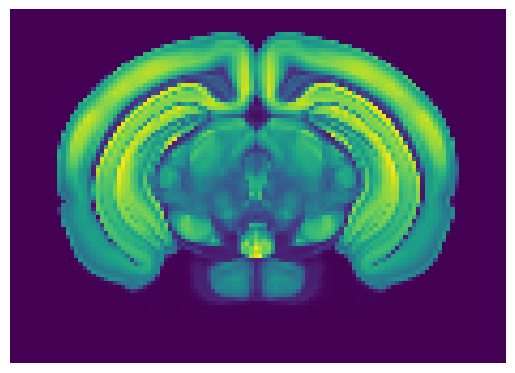

In [46]:
# display the low res slice

pose_id = 3

plt.imshow(img_lr.get_fdata().squeeze()[poses_ids_lowres[pose_id],:,:], aspect = 0.1/0.11)
plt.axis('off')

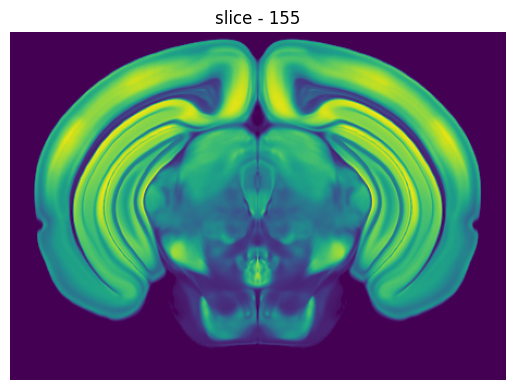

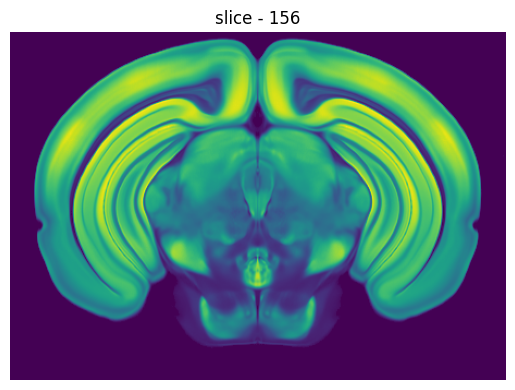

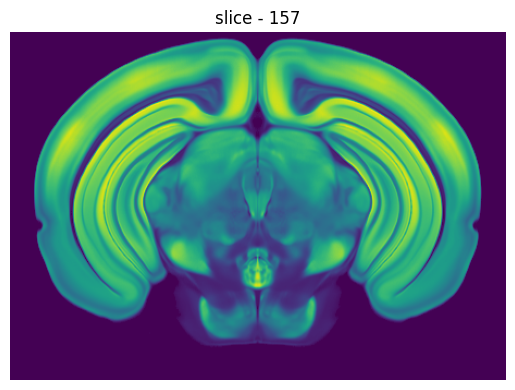

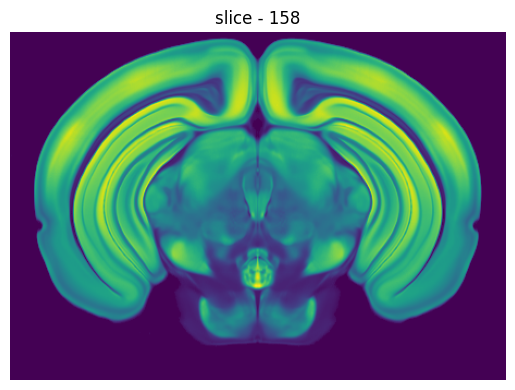

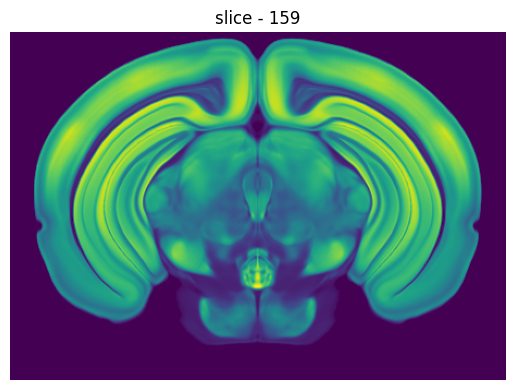

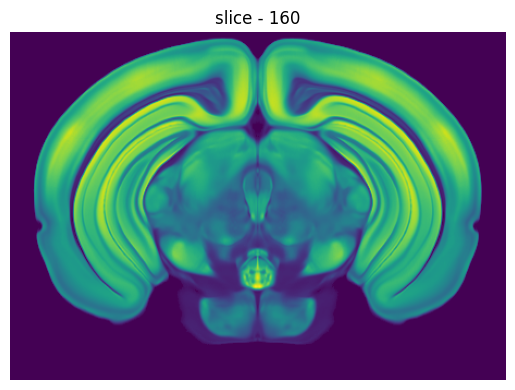

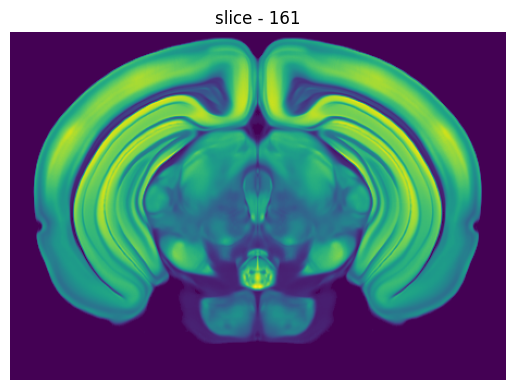

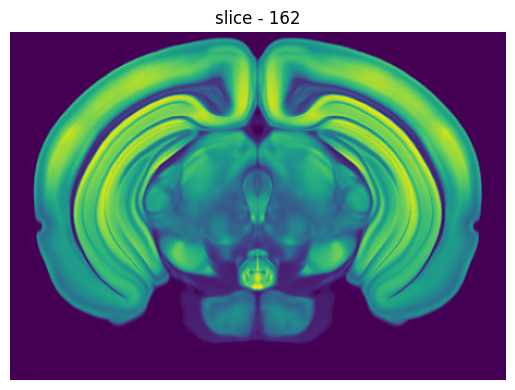

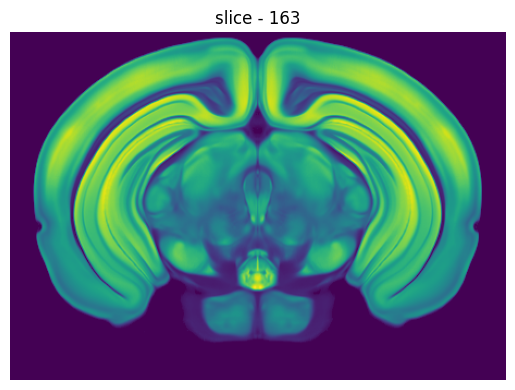

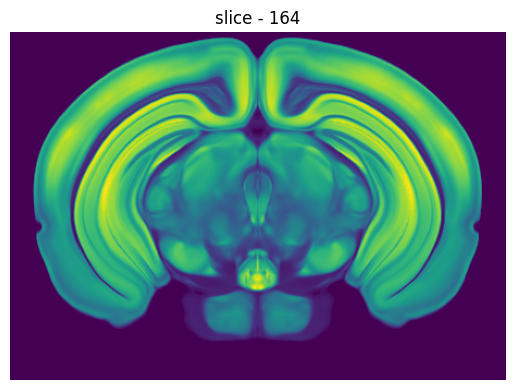

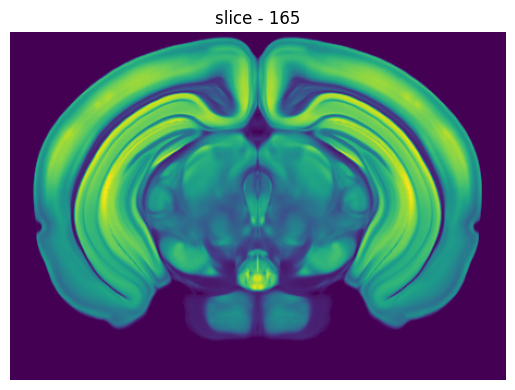

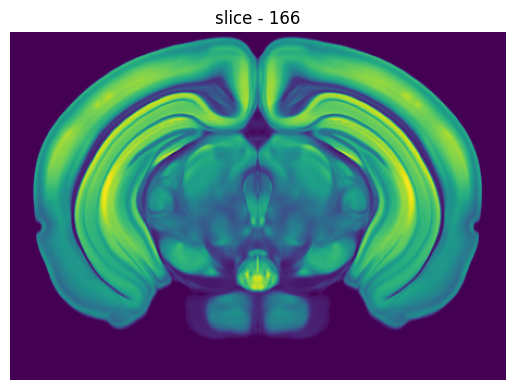

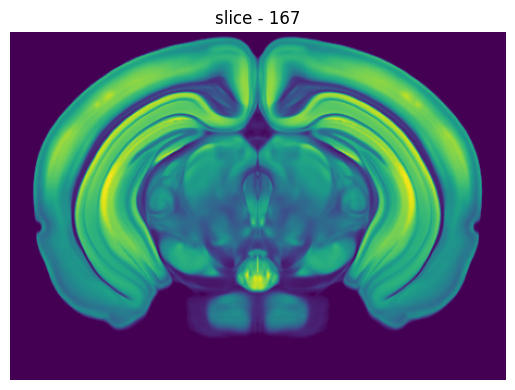

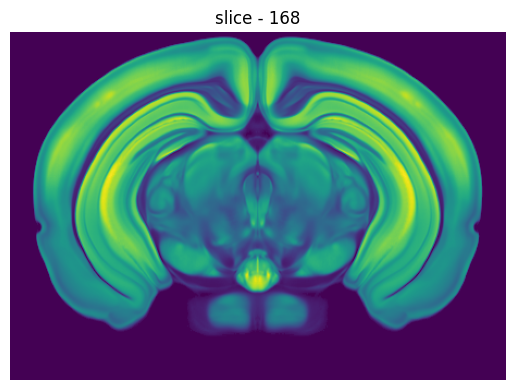

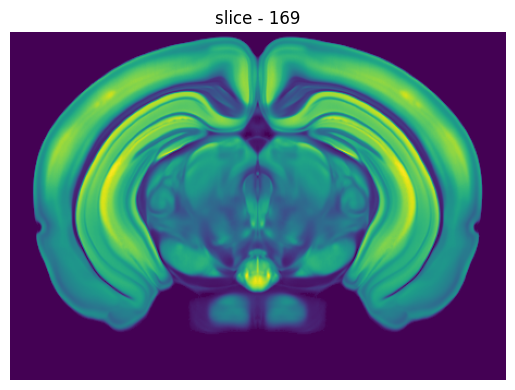

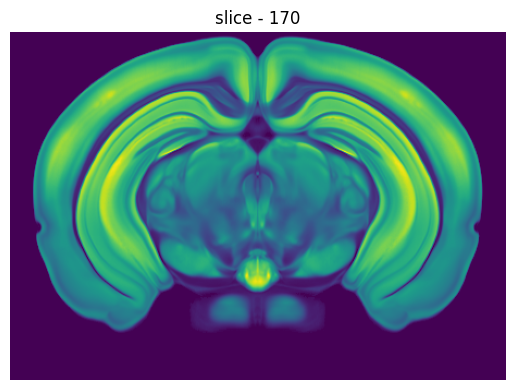

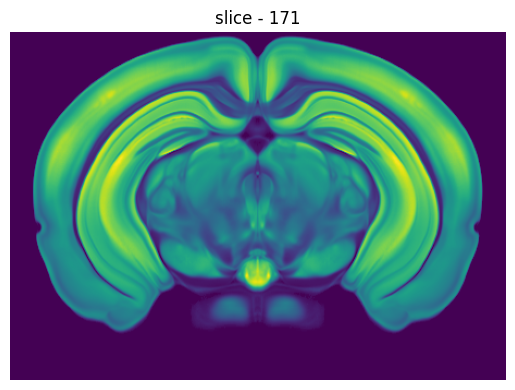

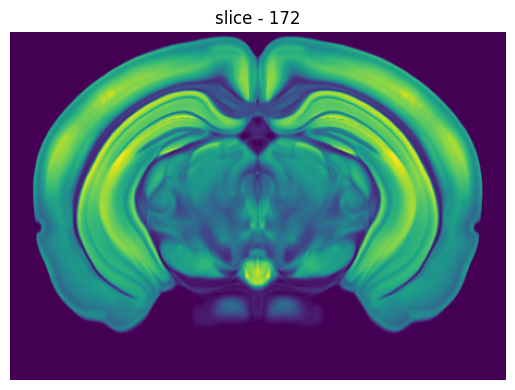

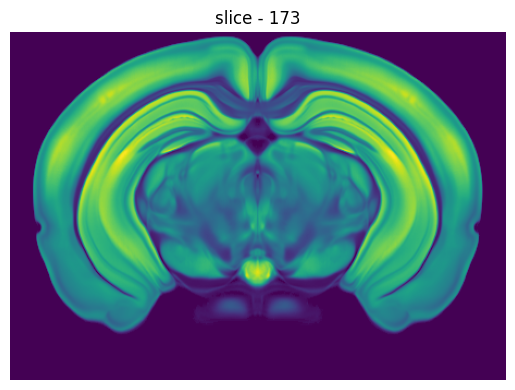

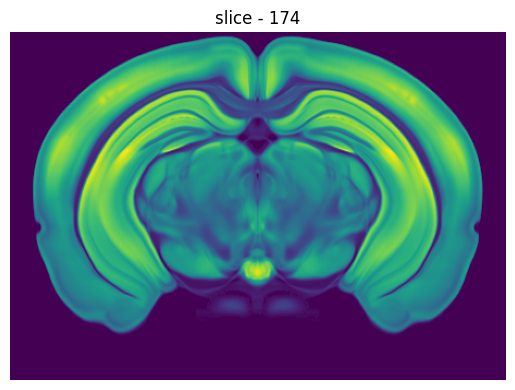

In [48]:
# check the high res equivalent

for i in range(155,175):

    plt.figure()
    plt.imshow(np.flip(img_hr.get_fdata().squeeze()[:,:,i].transpose([1,0])))
    plt.title(f'slice - {i}')

    plt.axis('off')

## Exports sliced high res

In [200]:
poses_ids_highres = np.array([285,245,205,165])

## slice-wise templates

In [201]:
save_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/Params/allen_templates/allen-25um/pose-template/')

for pose_id in range(4):
    
    # prefix = f'source-Wang2020_space-fUSIswVBm40_desc-AllenTemplate_res-25umx25umx25um_pose-{pose_id}_feature.nii.gz'
    prefix = f'source-gozzilab_space-Allen25um_desc-parcellationUnilateralDefaultN61_res-25umx25umx25um_pose-{pose_id}_feature.nii.gz'
    new_affine = np.diag(
        [-0.025, -0.025, 0.025, 1.0]
    )[[2,0,1,3],:]
    new_affine[2,-1] = -0.43
    new_affine[0,-1] = 0.65
    
    img_out = nib.Nifti1Image(
        np.flip(img_hr.get_fdata(), [0,1]).transpose([2,1,0])[poses_ids_highres[pose_id],:,:][None,:,:],
        affine = new_affine
    )
    
    nib.save(
        img_out,
        save_dir / prefix
    )

## Volume wise template for resampling in high res 

In [202]:
save_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/Params/allen_templates/allen-25um/pose-template/')

# prefix = f'source-Wang2020_space-fUSIswVBm40_desc-AllenTemplate_res-25umx25umx25um_pose-vol_feature.nii.gz'
prefix = f'source-gozzilab_space-Allen25um_desc-parcellationUnilateralDefaultN61_res-25umx25umx25um_pose-vol_feature.nii.gz'

# optimal affine for resampling
new_affine = np.diag(
    [-1.0, -0.025, 0.025, 1.0]
)[[2,0,1,3],:]
new_affine[2,-1] = -0.43
new_affine[0,-1] = 0.65

img_list = []

for pose_id in range(4):
    
    img_list.append(np.flip(img_hr.get_fdata(), [0,1]).transpose([2,1,0])[poses_ids_highres[pose_id],:,:][None,:,:])

img_out = nib.Nifti1Image(
    np.array(img_list).squeeze(),
    affine = new_affine
)

nib.save(
    img_out,
    save_dir / prefix
)

# From Allen-25um 2 fUSI-25um

This section is dedicated to transform images ouput from allen-ontology scripts in 25um resolution.

It follows these steps:
1. reorientation to abstract space of high resolution fUSI as transform was computed a long time ago in this weird space.
2. Apply the transform to match the high resolution fUSI space

These transforms should be followed by the next section dedicated to downsample to fUSI low resolution space

In [4]:
def apply_transformation_ants(
    file_name, 
    ref_name, 
    transform_path,
    output_dir,
    prefix = 'registered_image',
    interpolation = 'Linear',
    invert_transform_flag = [False]
):
    
    """
    Apply a transformation computed by ANTsRegistration
    """
    
    at = ApplyTransforms()

    at.inputs.dimension = 3
    at.inputs.input_image = str(file_name)
    at.inputs.reference_image = str(ref_name)
    at.inputs.output_image = str(output_dir / f'{prefix}.nii.gz')
    at.inputs.interpolation = interpolation
    at.inputs.default_value = 0
    at.inputs.transforms = str(transform_path)
    at.inputs.invert_transform_flags = invert_transform_flag

    at.cmdline
    
    at.run()
    
    return str(output_dir / f'{prefix}.nii.gz')

In [5]:
ref_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/Params/allen_templates/allen-25um/source/Allen-25_2_fUS-25/Allen-025mu_rotated.nii.gz')

transform_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/Params/allen_templates/allen-25um/source/Allen-25_2_fUS-25/transform_Affine_allen20-2-fUS25_Composite.h5')

# reference image in Allen 25um
source_ref_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/Params/allen_templates/allen-25um/source/Allen-25_2_fUS-25/source-Wang2020_desc-AllenMask_space-allen25um_res-25umx25umx25um_feature_reoriented_fUS25-from-allen25.nii.gz')
source_ref_img = nib.load(source_ref_name)

# Image to be transformed
source_name = Path('/media/DATA2/JC/1_DATA/2025-01-23_allen/2025-01-23_standardised_parcellation/parcellations/parcellation_N53_mila_25um/bilateral/00_Allen-25um/source-gozzilab_space-Allen25um_desc-parcellationBilateralDefaultN53_res-25umx25umx25um_feature.nii.gz')
source_img = nib.load(source_name)

# output folder
save_dir = Path('/media/DATA2/JC/3_Trash/2025-08-26_Milas-stuff/2025-08-26_parcellation/')

In [7]:
out_img = nib.Nifti1Image(
    np.flip(source_img.get_fdata().transpose([2,1,0]), [1,2]),
    affine = source_ref_img.affine
)

nib.save(
    out_img,
    save_dir / (source_name.name.split('.nii.gz')[0] + '_reoriented.nii.gz')
)

In [8]:
reoriented_path = save_dir / (source_name.name.split('.nii.gz')[0] + '_reoriented.nii.gz')

prefix = (source_name.name.split('.nii.gz')[0] + '_reoriented_fUS25-from-allen25')

In [9]:
apply_transformation_ants(
    reoriented_path, 
    ref_name, 
    transform_path,
    save_dir,
    prefix = prefix,
    interpolation = 'NearestNeighbor',
    invert_transform_flag = [False]
)

'/media/DATA2/JC/3_Trash/2025-08-26_Milas-stuff/2025-08-26_parcellation/source-gozzilab_space-Allen25um_desc-parcellationBilateralDefaultN53_res-25umx25umx25um_feature_reoriented_fUS25-from-allen25.nii.gz'

# From fUSI-25um 2 fUSI-100um

The following cells allow to downsample images from fUSI 25um (output of the previous section) to fUSI low res both in volume and sliced spaces.

Be aware that volume and sliced space use two different strategies:

- **Volume:** the affine is imposed by *isotropic fUSI PIRRAS minimal affine space*, this space is defined when the fUSI template is oriented as PIRRAS and the affine is minimal (no translation) to allow PIRRAS orientation while respecting real world dimension (pixdim).
- **Slice wise:** the affine is imposed by arbitrary minimal affine defined in the previous section. 

## Entire volume

Here images are output in volume (*i.e.* isotropic angiographic reference template equivalence)

In [64]:
# affine to reorient abstract high res fUSI space to isotropic fUSI PIRRAS minimal affine space

new_affine = np.diag([1.0,1.0,-1.0,1.0])[[0,2,1,3],:] @ img.affine
new_affine[:3,-1] = new_affine[:3,-1]+[
    (115*0.11/2-455*0.025/2),
    (304-122)*0.025,
    -9.0+(315-295)*0.025
]


# low resolution fUSI isotropic volume image
ref_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz')
ref_img = nib.load(ref_name)

file_name = Path('/media/DATA2/JC/3_Trash/2025-08-26_Milas-stuff/2025-08-26_parcellation/source-gozzilab_space-Allen25um_desc-parcellationBilateralDefaultN53_res-25umx25umx25um_feature_reoriented_fUS25-from-allen25.nii.gz')
img = nib.load(file_name)

csv_name = Path('/media/DATA2/JC/1_DATA/2025-01-23_allen/2025-01-23_standardised_parcellation/parcellations/parcellation_N53_mila_25um/bilateral/00_Allen-25um/source-gozzilab_space-Allen25um_desc-parcellationBilateralDefaultN53_res-25umx25umx25um_feature.csv')
csv_df = pd.read_csv(csv_name)

print(csv_df.head(5))

print('\n\n...\n\n')
print(csv_df.tail(5))

      acro  allen_ids  parcel_ids networks       side
0      FRP        184           1      LCN  bilateral
1      MOp        985           2      LCN  bilateral
2      MOs        993           3   DMNmid  bilateral
3    SSp-n        353           4      LCN  bilateral
4  SSp-bfd        329           5   DMNpln  bilateral


...


    acro  allen_ids  parcel_ids networks       side
48   MRN        128          49    DMNth  bilateral
49   SCm        294          50   DMNpln  bilateral
50   PAG        795          51    DMNth  bilateral
51   PRT       1100          52    DMNth  bilateral
52  RAmb        165          53       HC  bilateral


In [65]:

# reorient the high res image for resampling

img_out = nib.Nifti1Image(
    img.get_fdata(),
    affine = new_affine
)

# resamples in low res angio space (isotropic fUSI PIRRAS minimal affine space)

downsampled_img = resample_img(
    img_out,
    target_affine=ref_img.affine,
    target_shape=ref_img.shape,
    interpolation='nearest'
)

/tmp/ipykernel_3999/4140596420.py:13: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  downsampled_img = resample_img(
/tmp/ipykernel_3999/4140596420.py:13: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  downsampled_img = resample_img(


In [66]:
# saves the downsampled image

save_name = file_name.parent / f'{file_name.name.split(".nii.gz")[0]}_fUSI100vol-from-fUSI25.nii.gz'
nib.save(
    downsampled_img,
    save_name
)

### Parameters

### Downsampling

## Slice wise

Here images are output in slice (*i.e.* functional images). Both spaces share the same coordinate system for convenience, but the real world grids differ.

#### Parameters

In [10]:
# low resolution fUSI sliced reference image
ref_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/Params/allen_templates/allen-100um/source-Wang2020_space-fUSIswVBm40_desc-AllenTemplate_res-110umx100umx100um_pose-vol_feature.nii.gz')
ref_img = nib.load(ref_name)

file_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/Params/allen_templates/allen-25um/pose-template/source-gozzilab_space-Allen25um_desc-parcellationBilateralDefaultN61_res-25umx25umx25um_pose-vol_feature.nii.gz')
img = nib.load(file_name)

csv_name = Path('/media/DATA2/JC/1_DATA/2025-01-23_allen/2025-01-23_standardised_parcellation/parcellations/parcellation_fUSIN51/bilateral/00_Allen-100um/source-gozzilab_space-Allen25um_desc-parcellationBilateralDefaultN61_res-100umx100umx100um_feature.csv')
csv_df = pd.read_csv(csv_name)

print(csv_df.head(5))

print('\n\n...\n\n')
print(csv_df.tail(5))

      acro  allen_ids  parcel_ids       side
0      MOp        985           1  bilateral
1      MOs        993           2  bilateral
2  SSp-bfd        329           3  bilateral
3   SSp-ll        337           4  bilateral
4   SSp-ul        369           5  bilateral


...


     acro  allen_ids  parcel_ids       side
56    PVZ        157          57  bilateral
57    MEZ        467          58  bilateral
58     LZ        290          59  bilateral
59  MBsen        339          60  bilateral
60  MBmot        323          61  bilateral


#### Downsampling

In [14]:
downsampled_img = resample_img(
    img,
    target_affine=ref_img.affine,
    target_shape=ref_img.shape,
    interpolation='nearest'
)

/tmp/ipykernel_3657982/3114526286.py:1: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  downsampled_img = resample_img(
/tmp/ipykernel_3657982/3114526286.py:1: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  downsampled_img = resample_img(


#### Slicing

The following cells are required for parcellation slicing to re-assign labels to annotation and update parcellation .csv file as some parcels might disappear during slicing/downsampling.

In [368]:
sliced_csv_data = {
    'acro':[],
    'allen_ids':[],
    'parcel_ids':[],
    'side':[]
}

sliced_resampled_data = np.zeros(
    downsampled_img.shape
)

k = 1

for i, (acro, parcel_ids, side, allen_ids) in enumerate(zip(
    csv_df['acro'],
    csv_df['parcel_ids'],
    csv_df['side'],
    csv_df['allen_ids']
)):

    if (downsampled_img.get_fdata() == parcel_ids).sum() > 0:

        sliced_csv_data['acro'].append(acro)
        sliced_csv_data['allen_ids'].append(allen_ids)
        sliced_csv_data['parcel_ids'].append(k)
        sliced_csv_data['side'].append(side)

        sliced_resampled_data[downsampled_img.get_fdata() == parcel_ids] = k
        
        k = k+1

sliced_resampled_img = nib.Nifti1Image(
    sliced_resampled_data,
    affine = downsampled_img.affine,
    header = downsampled_img.header
)

sliced_csv_df = pd.DataFrame(sliced_csv_data)

In [369]:
print(sliced_csv_df.head(5))
print('\n\n...\n\n')
print(sliced_csv_df.tail(5))

      acro  allen_ids  parcel_ids       side
0      MOp        985           1  bilateral
1      MOs        993           2  bilateral
2  SSp-bfd        329           3  bilateral
3   SSp-ll        337           4  bilateral
4   SSp-ul        369           5  bilateral


...


     acro  allen_ids  parcel_ids       side
49  DORpm        856          50  bilateral
50    PVZ        157          51  bilateral
51    MEZ        467          52  bilateral
52     LZ        290          53  bilateral
53  MBmot        323          54  bilateral


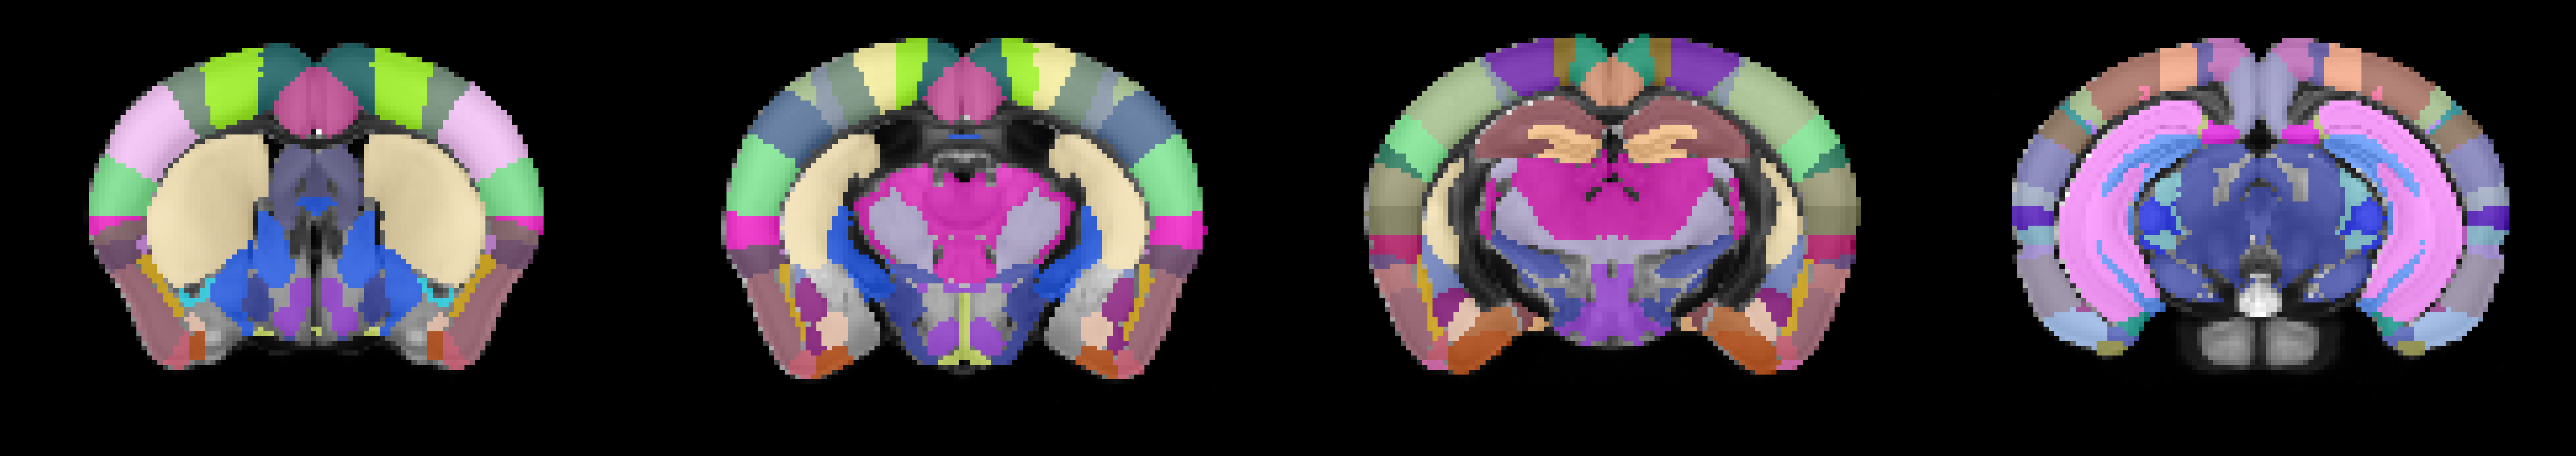

In [370]:
nb_lin = 1
nb_col = 4

fig, ax = plt.subplots(
    nb_lin, nb_col, figsize=(7*nb_col, 5*nb_lin), dpi = 200, facecolor = 'k'
)

for slice_id in range(4):

    img_2_display = ref_img.get_fdata()[slice_id,:,:]
    ax[slice_id].imshow(img_2_display, aspect = 0.1/0.11, cmap = 'Greys_r')
    
    img_2_display = sliced_resampled_img.get_fdata()[slice_id,:,:]
    alpha = img_2_display > 0
    ax[slice_id].imshow(img_2_display, aspect = 0.1/0.11, cmap = cc.cm['glasbey'], alpha = 0.7*alpha)
    
    ax[slice_id].axis('off')

plt.tight_layout()

In [371]:
save_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/Params/allen_templates/fUSI-100um/')

save_name = save_dir / f'source-gozzilab_space-fUSI100_desc-parcellationBilateralDefaultN{int(np.max(sliced_resampled_img.get_fdata()))}_res-100umx100umx100um_pose-vol_feature.nii.gz'

nib.save(
    sliced_resampled_img,
    save_name
)

save_name = save_dir / f'source-gozzilab_space-fUSI100_desc-parcellationBilateralDefaultN{int(np.max(sliced_resampled_img.get_fdata()))}_res-100umx100umx100um_pose-vol_feature.csv'

sliced_csv_df.to_csv(save_name)

### Exporting ROIs

#### Bilateral

In [374]:
file_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/Params/parcellations/source-gozzilab_space-fUSI100_desc-parcellationBilateralDefaultN54_res-100umx100umx100um_pose-vol_feature.nii.gz')
parcel_img = nib.load(file_name)
csv_name = file_name.parent / f'{file_name.name.split('.nii.gz')[0]}.csv'
parcel_df = pd.read_csv(csv_name, index_col = 0)

# selected_ROIs = ['SSp-n', 'SSp-ul', 'SSp-bfd', 'SSs', 'MOp', 'MOs', 'ACA', 'STRd', 'PIR', 'DORsm', 'DORpm', 'CA', 'DG', 'RSPd', 'PTLp', 'MBmot']
selected_ROIs = ['MOp', 'MOs', 'SSp-m', 'SSp-un', 'SSp-n', 'SSs', 'AUDv', 'VISp', 'AIp', 'ACA', 'RSPd', 'PTLp', 'PIR', 'COA', 'CA', 'DG', 'STRd', 'DORsm', 'DORpm', 'MBmot']

selection_tag = 'CP-20'

for roi_acro in selected_ROIs:

    if roi_acro in list(parcel_df['acro'][:]):

        print(f'{roi_acro} : OK')

    else:

        print(f'{roi_acro} : \t\tERROR')

parcellation_tag = file_name.name.split('desc-')[1].split('_')[0]

save_dir = file_name.parent / parcellation_tag / ('whole-ROI_' + selection_tag)
save_dir.mkdir(parents = True, exist_ok = True)

MOp : OK
MOs : OK
SSp-m : OK
SSp-un : OK
SSp-n : OK
SSs : OK
AUDv : OK
VISp : OK
AIp : OK
ACA : OK
RSPd : OK
PTLp : OK
PIR : OK
COA : OK
CA : OK
DG : OK
STRd : OK
DORsm : OK
DORpm : OK
MBmot : OK


In [375]:
for roi_acro in tqdm(selected_ROIs):

    roi_id = parcel_df['parcel_ids'][parcel_df['acro'] == roi_acro].values[0]

    roi_img = math_img(f'a == {roi_id}', a = parcel_img)

    save_name = save_dir / f'{parcellation_tag}_ROI-{roi_id}_{roi_acro}_wholeRoi.nii.gz'

    nib.save(roi_img, save_name)

100%|███████████████████████████████████████████████| 20/20 [00:11<00:00,  1.80it/s]


Text(0.5, 0.98, 'RSPd')

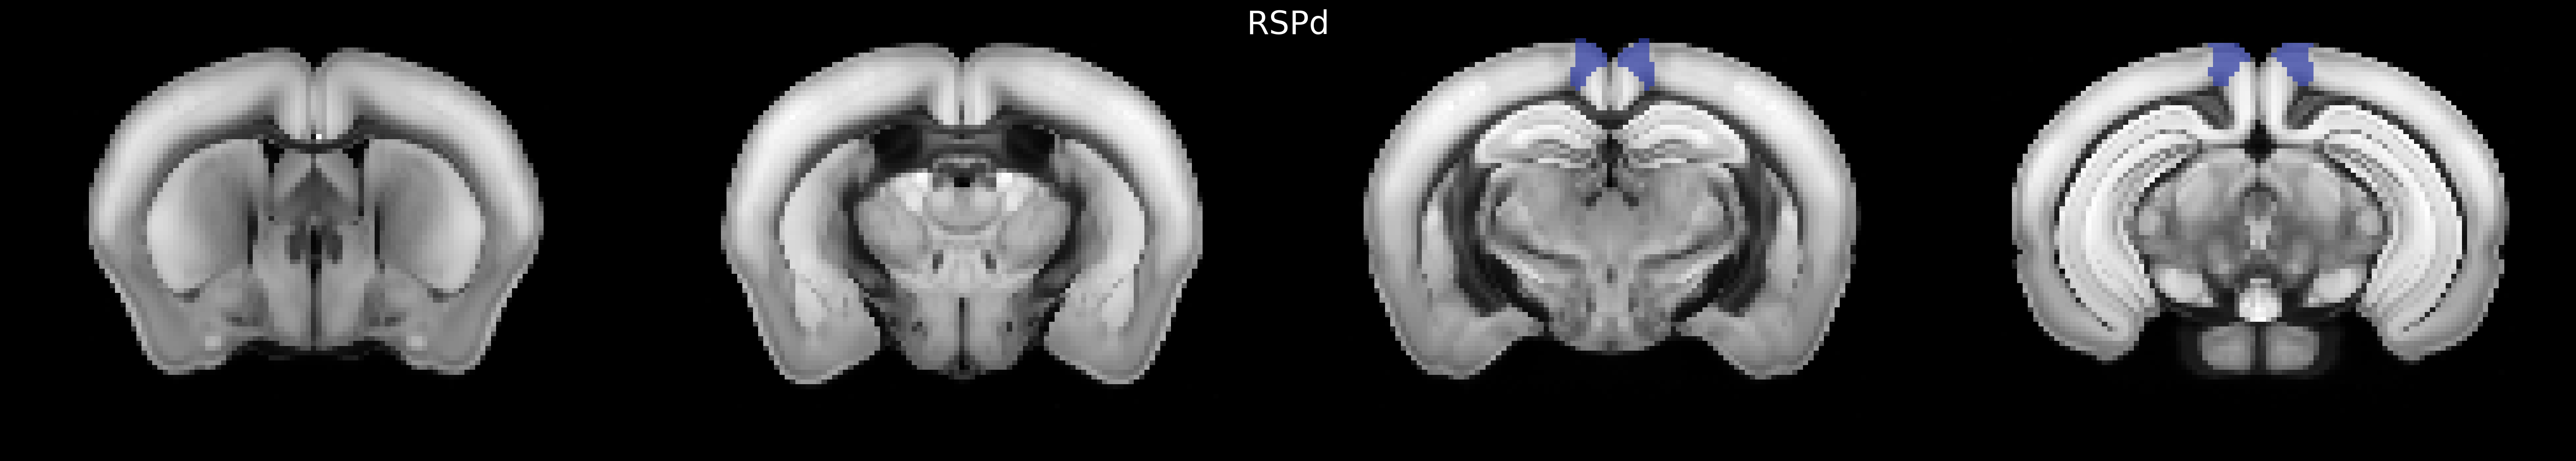

In [310]:
roi_acro = selected_ROIs[10]

roi_id = parcel_df['parcel_ids'][parcel_df['acro'] == roi_acro].values[0]

roi_img = math_img(f'a == {roi_id}', a = parcel_img)

nb_lin = 1
nb_col = 4

fig, ax = plt.subplots(
    nb_lin, nb_col, figsize=(7*nb_col, 5*nb_lin), dpi = 200, facecolor = 'k'
)

for slice_id in range(4):

    img_2_display = ref_img.get_fdata()[slice_id,:,:]
    ax[slice_id].imshow(img_2_display, aspect = 0.1/0.11, cmap = 'Greys_r')
    
    img_2_display = roi_img.get_fdata()[slice_id,:,:]
    alpha = img_2_display > 0
    ax[slice_id].imshow(img_2_display, aspect = 0.1/0.11, cmap = cc.cm['glasbey'], alpha = 0.7*alpha)
    
    ax[slice_id].axis('off')

plt.tight_layout()

plt.suptitle(f'{roi_acro}', c = 'w', fontsize = 25)

#### Unilateral

In [376]:
file_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/Params/parcellations/source-gozzilab_space-fUSI100_desc-parcellationUnilateralDefaultN54_res-100umx100umx100um_pose-vol_feature.nii.gz')
parcel_img = nib.load(file_name)
csv_name = file_name.parent / f'{file_name.name.split('.nii.gz')[0]}.csv'
parcel_df = pd.read_csv(csv_name, index_col = 0)

# selected_ROIs = ['SSp-n', 'SSp-ul', 'SSp-bfd', 'SSs', 'MOp', 'MOs', 'ACA', 'STRd', 'PIR', 'DORsm', 'DORpm', 'CA', 'DG', 'RSPd', 'PTLp', 'MBmot']
selected_ROIs = ['MOp', 'MOs', 'SSp-m', 'SSp-un', 'SSp-n', 'SSs', 'AUDv', 'VISp', 'AIp', 'ACA', 'RSPd', 'PTLp', 'PIR', 'COA', 'CA', 'DG', 'STRd', 'DORsm', 'DORpm', 'MBmot']

selection_tag = 'CP-20'

for roi_acro in selected_ROIs:

    if roi_acro in list(parcel_df['acro'][:]):

        print(f'{roi_acro} : OK')

    else:

        print(f'{roi_acro} : \t\tERROR')

parcellation_tag = file_name.name.split('desc-')[1].split('_')[0]

save_dir = file_name.parent / parcellation_tag / ('whole-ROI_' + selection_tag)
save_dir.mkdir(parents = True, exist_ok = True)

MOp : OK
MOs : OK
SSp-m : OK
SSp-un : OK
SSp-n : OK
SSs : OK
AUDv : OK
VISp : OK
AIp : OK
ACA : OK
RSPd : OK
PTLp : OK
PIR : OK
COA : OK
CA : OK
DG : OK
STRd : OK
DORsm : OK
DORpm : OK
MBmot : OK


In [379]:
for roi_acro in tqdm(selected_ROIs):

    roi_id = parcel_df['parcel_ids'][(parcel_df['acro'] == roi_acro) & (parcel_df['side'] == 'unilateralLeft')].values[0]

    # roi_img = math_img(f'a == {roi_id}', a = parcel_img)
    roi_data = parcel_img.get_fdata() == roi_id
    [X,Y,Z] = roi_data.shape

    # Left
    
    roi_img = nib.Nifti1Image(
        roi_data,
        affine = parcel_img.affine,
        header = parcel_img.header
    )

    save_name = save_dir / f'{parcellation_tag}_ROI-{roi_id}_{roi_acro}-Left_wholeRoi.nii.gz'

    nib.save(roi_img, save_name)

    # Right

    roi_id = parcel_df['parcel_ids'][(parcel_df['acro'] == roi_acro) & (parcel_df['side'] == 'unilateralRight')].values[0]

    # roi_img = math_img(f'a == {roi_id}', a = parcel_img)
    roi_data = parcel_img.get_fdata() == roi_id
    [X,Y,Z] = roi_data.shape

    # Left
    
    roi_img = nib.Nifti1Image(
        roi_data,
        affine = parcel_img.affine,
        header = parcel_img.header
    )

    save_name = save_dir / f'{parcellation_tag}_ROI-{roi_id}_{roi_acro}-Right_wholeRoi.nii.gz'

    nib.save(roi_img, save_name)

100%|██████████████████████████████████████████████| 20/20 [00:00<00:00, 169.51it/s]


#### Single slice


In [393]:
root_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/Params/parcellations/parcellationUnilateralDefaultN54/whole-ROI_CP-20/01_right/')

root_dir = sorted([x for x in root_name.iterdir() if x.is_file() and re.match(f'^.*.nii.gz$', x.name)])

save_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/Params/parcellations/parcellationUnilateralDefaultN54/whole-ROI_CP-20/01_right_single-slice/')
save_dir.mkdir(exist_ok = True, parents = True)

In [394]:
for file_name in root_dir:
    
    img = nib.load(file_name)
    
    data_out = np.zeros(img.shape)
    ind = np.argmax(img.get_fdata().sum((1,2)))
    
    data_out[ind,:,:] = img.get_fdata()[ind,:,:]
    
    img_out = nib.Nifti1Image(
        data_out,
        affine = img.affine,
        header = img.header
    )
    
    save_name = save_dir / file_name.name.replace('wholeRoi', 'singleSlice')
    
    nib.save(
        img_out,
        save_name
    )

# test

In [104]:
from nilearn.image import math_img, resample_img
from scipy.ndimage import binary_fill_holes

In [97]:
template_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/Params/allen_templates/allen-25um/pose-template/source-Wang2020_space-fUSIswVBm40_desc-AllenTemplate_res-25umx25umx25um_pose-vol_feature.nii.gz')
template_img = nib.load(template_name)

In [78]:
file_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/02_preprocessing/derivatives/scrub/sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-vol_proc-choppedSWregisteredREGlowIntensitySignalFilteredSmoothedSTCscrubbed_pwd.nii.gz')
img = nib.load(file_name)

In [87]:
pseudo_cap_img = math_img('a[:,:,:,a.mean((0,1,2))>np.percentile(a.mean((0,1,2)),98)].mean(-1)', a = img)

In [88]:
pseudo_cap_img.shape

(4, 91, 116)

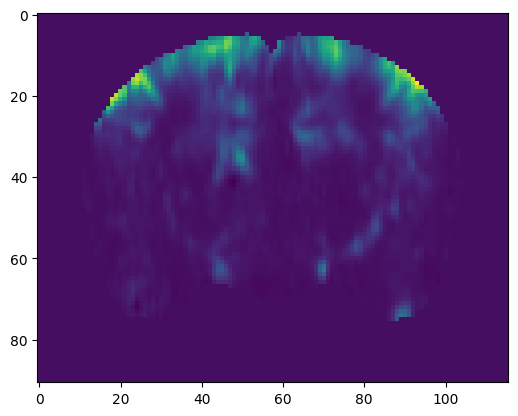

In [91]:
plt.imshow(pseudo_cap_img.get_fdata()[2,:,:])

In [101]:
pseudo_cap_highres = resample_img(
    pseudo_cap_img,
    target_affine = template_img.affine,
    target_shape = template_img.shape,
)

/tmp/ipykernel_1514061/175096230.py:1: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  pseudo_cap_highres = resample_img(
/tmp/ipykernel_1514061/175096230.py:1: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  pseudo_cap_highres = resample_img(


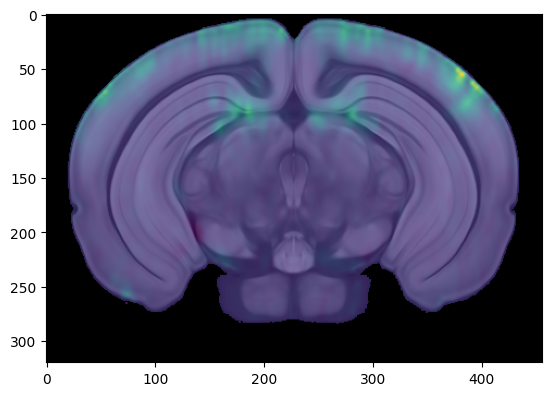

In [109]:
slice_id = 3

img_2_display = template_img.get_fdata()[slice_id,:,:]
plt.imshow(
    img_2_display,
    cmap = 'Greys_r'
)
local_mask = binary_fill_holes(img_2_display)

img_2_display = pseudo_cap_highres.get_fdata()[slice_id,:,:]*local_mask
plt.imshow(img_2_display, alpha = 0.7*local_mask)

In [102]:
pseudo_cap_highres.shape

(4, 320, 456)

In [100]:
img.affine

array([[ 0.  ,  0.  ,  0.11,  0.  ],
       [-1.  ,  0.  ,  0.  ,  0.  ],
       [ 0.  , -0.1 ,  0.  ,  0.  ],
       [ 0.  ,  0.  ,  0.  ,  1.  ]])